In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (15, 6)

try:
    pop_region_df = pop_with_region.copy()
    print("Using existing variable: pop_with_region")
except NameError:
    pop_region_df = pd.read_csv("/Users/tonytony/Final Project/Data/Cleaned/pop_with_wb_region.csv")
    print("Loaded file: pop_with_wb_region.csv")

print("Shape:", pop_region_df.shape)
pop_region_df.head()


Loaded file: pop_with_wb_region.csv
Shape: (266, 75)


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2021,2022,2023,2024,Unnamed: 69,WB Region,Admin Region,Income Level,Lending Type,Country Type
0,Aruba,ABW,"Population, total",SP.POP.TOTL,54922.0,55578.0,56320.0,57002.0,57619.0,58190.0,...,107700.0,107310.0,107359.0,107995.0,NaN,Latin America & Caribbean,NaN,High income,Not classified,Country/Territory
1,Africa Eastern and Southern,AFE,"Population, total",SP.POP.TOTL,130075728.0,133534923.0,137171659.0,140945536.0,144904094.0,149033472.0,...,713090928.0,731821393.0,750491370.0,769280888.0,NaN,Aggregates,NaN,Aggregates,Aggregates,Aggregate
2,Afghanistan,AFG,"Population, total",SP.POP.TOTL,9035043.0,9214083.0,9404406.0,9604487.0,9814318.0,10036008.0,...,40000412.0,40578842.0,41454761.0,42647492.0,NaN,"Middle East, North Africa, Afghanistan & Pakistan","Middle East, North Africa, Afghanistan & Pakis...",Low income,IDA,Country/Territory
3,Africa Western and Central,AFW,"Population, total",SP.POP.TOTL,97630925.0,99706674.0,101854756.0,104089175.0,106388440.0,108772632.0,...,485920997.0,497387180.0,509398589.0,521764076.0,NaN,Aggregates,NaN,Aggregates,Aggregates,Aggregate
4,Angola,AGO,"Population, total",SP.POP.TOTL,5231654.0,5301583.0,5354310.0,5408320.0,5464187.0,5521981.0,...,34532429.0,35635029.0,36749906.0,37885849.0,NaN,Sub-Saharan Africa,Sub-Saharan Africa (excluding high income),Lower middle income,IBRD,Country/Territory


In [2]:
if "Country Type" not in pop_region_df.columns:
    pop_region_df["Country Type"] = pop_region_df["WB Region"].apply(
        lambda x: "Aggregate" if str(x).strip() == "Aggregates" else "Country/Territory"
    )

year_cols = [col for col in pop_region_df.columns if str(col).isdigit()]
pop_region_df[year_cols] = pop_region_df[year_cols].apply(pd.to_numeric, errors="coerce")

pop_long = pop_region_df.melt(
    id_vars=["Country Name", "Country Code", "WB Region", "Country Type"],
    value_vars=year_cols,
    var_name="Year",
    value_name="Population, total"
)

pop_long["Year"] = pd.to_numeric(pop_long["Year"], errors="coerce").astype("Int64")
pop_long["Population, total"] = pd.to_numeric(pop_long["Population, total"], errors="coerce")

pop_long = pop_long[
    (pop_long["Country Type"] == "Country/Territory") &
    (pop_long["WB Region"].notna()) &
    (pop_long["Population, total"].notna()) &
    (pop_long["Population, total"] > 0)
].copy()

print("Long-format Population dataset shape:", pop_long.shape)
print("Year range:", int(pop_long["Year"].min()), "-", int(pop_long["Year"].max()))
print("Number of countries/territories:", pop_long["Country Code"].nunique())

pop_long.head()


Long-format Population dataset shape: (14075, 6)
Year range: 1960 - 2024
Number of countries/territories: 217


,Country Name,Country Code,WB Region,Country Type,Year,"Population, total"
0,Aruba,ABW,Latin America & Caribbean,Country/Territory,1960,54922.0
2,Afghanistan,AFG,"Middle East, North Africa, Afghanistan & Pakistan",Country/Territory,1960,9035043.0
4,Angola,AGO,Sub-Saharan Africa,Country/Territory,1960,5231654.0
5,Albania,ALB,Europe & Central Asia,Country/Territory,1960,1608800.0
6,Andorra,AND,Europe & Central Asia,Country/Territory,1960,9510.0


In [3]:
pop_global_trend = (
    pop_long
    .groupby("Year")
    .agg(
        country_count=("Country Code", "nunique"),
        total_population=("Population, total", "sum"),
        mean_population=("Population, total", "mean"),
        median_population=("Population, total", "median"),
        min_population=("Population, total", "min"),
        max_population=("Population, total", "max")
    )
    .reset_index()
)

pop_region_trend = (
    pop_long
    .groupby(["WB Region", "Year"])
    .agg(
        country_count=("Country Code", "nunique"),
        total_population=("Population, total", "sum"),
        mean_population=("Population, total", "mean"),
        median_population=("Population, total", "median"),
        min_population=("Population, total", "min"),
        max_population=("Population, total", "max")
    )
    .reset_index()
    .sort_values(["WB Region", "Year"])
)

pop_region_trend["regional_growth_rate_pct"] = (
    pop_region_trend
    .groupby("WB Region")["total_population"]
    .pct_change() * 100
)

pop_region_trend = pop_region_trend.merge(
    pop_global_trend[["Year", "total_population"]].rename(
        columns={"total_population": "global_total_population"}
    ),
    on="Year",
    how="left"
)

pop_region_trend["population_share_pct"] = (
    pop_region_trend["total_population"] /
    pop_region_trend["global_total_population"] * 100
)

print("Global trend shape:", pop_global_trend.shape)
print("Regional trend shape:", pop_region_trend.shape)

pop_global_trend.head()


Global trend shape: (65, 7)
Regional trend shape: (455, 11)


,Year,country_count,total_population,mean_population,median_population,min_population,max_population
0,1960,216,3.010811e+09,1.393894e+07,2364900.0,2715.0,667070000.0
1,1961,216,3.051696e+09,1.412822e+07,2409711.0,2970.0,660330000.0
2,1962,216,3.105920e+09,1.437926e+07,2466161.0,3264.0,665770000.0
3,1963,216,3.172221e+09,1.468621e+07,2518165.0,3584.0,682335000.0
4,1964,216,3.239012e+09,1.499542e+07,2569733.0,3922.0,698355000.0


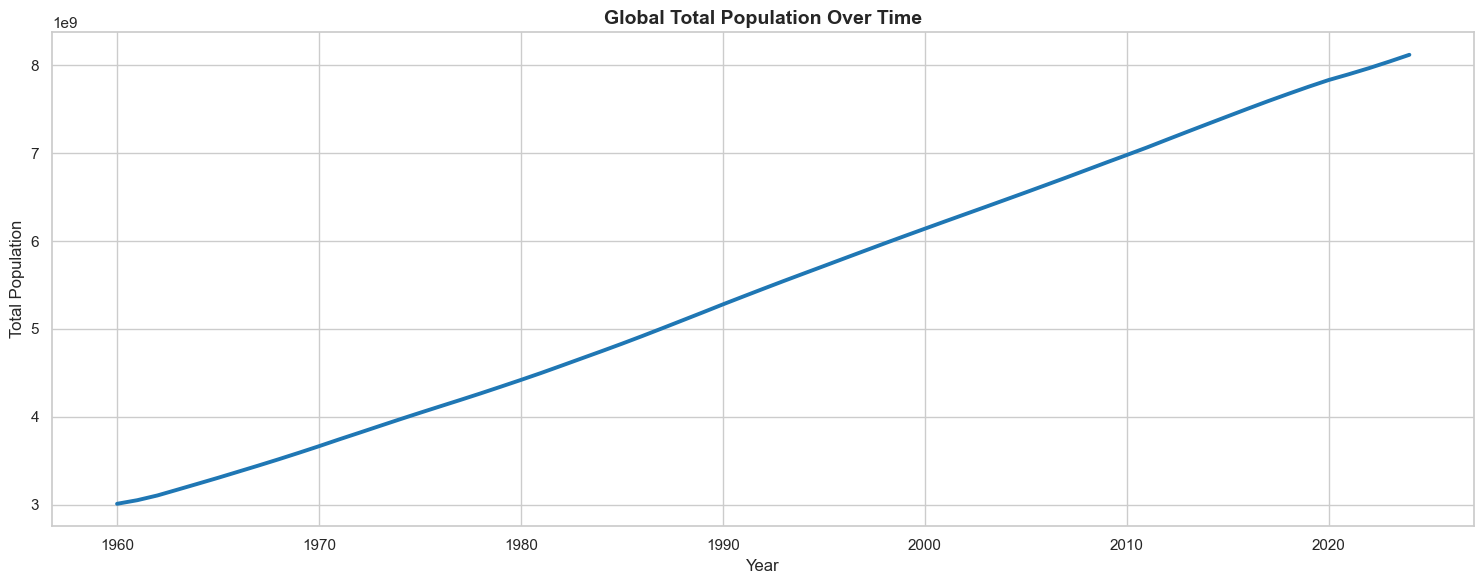

In [4]:
plt.figure(figsize=(15, 6))

sns.lineplot(
    data=pop_global_trend,
    x="Year",
    y="total_population",
    linewidth=2.8,
    color="#1f77b4"
)

plt.title("Global Total Population Over Time", fontsize=14, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Total Population")
plt.tight_layout()
plt.show()


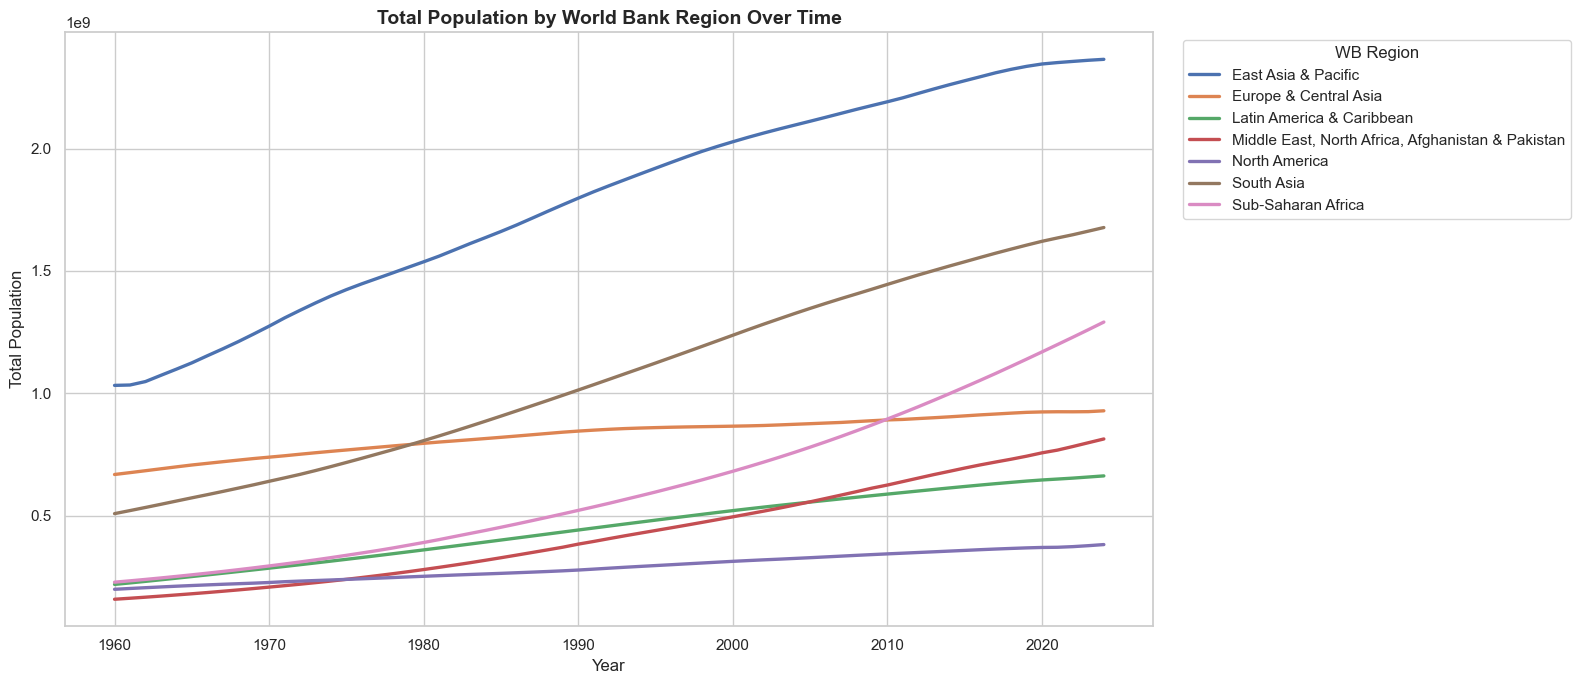

In [5]:
plt.figure(figsize=(16, 7))

sns.lineplot(
    data=pop_region_trend,
    x="Year",
    y="total_population",
    hue="WB Region",
    linewidth=2.4
)

plt.title("Total Population by World Bank Region Over Time", fontsize=14, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Total Population")
plt.legend(title="WB Region", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


### Insight - Total Population by World Bank Region

This chart shows clear differences in total population size across regions.

Key observations:
- Some regions contain a much larger share of the world population than others.
- Regions in Asia-related areas tend to remain dominant in total population.
- Other regions may show clear growth over time, but still remain much smaller in absolute population size.

Conclusion:
Population is highly concentrated in a limited number of regions, and the regional distribution of population is clearly uneven.


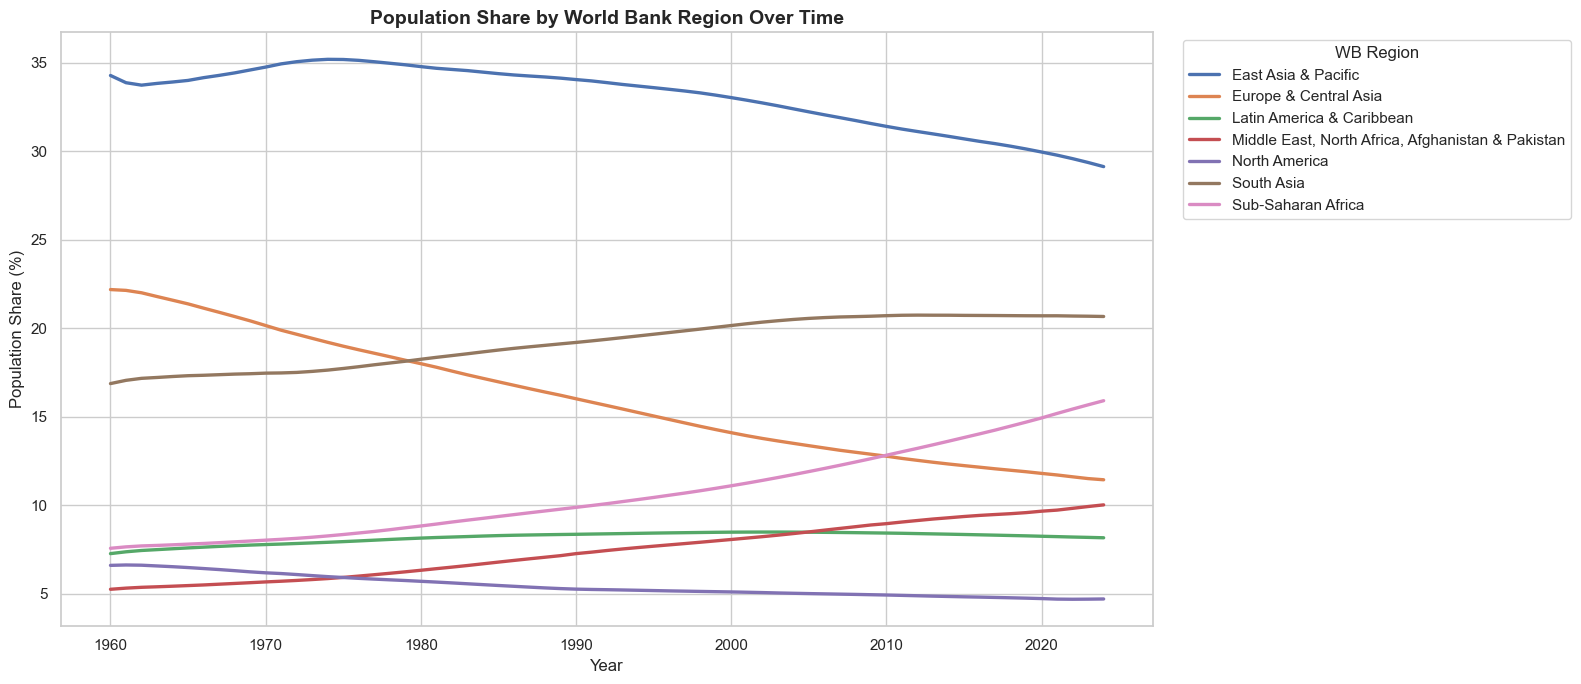

In [6]:
plt.figure(figsize=(16, 7))

sns.lineplot(
    data=pop_region_trend,
    x="Year",
    y="population_share_pct",
    hue="WB Region",
    linewidth=2.4
)

plt.title("Population Share by World Bank Region Over Time", fontsize=14, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Population Share (%)")
plt.legend(title="WB Region", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


### Insight - Population Share by Region

This chart focuses on relative contribution rather than absolute population size.

Key observations:
- Some regions maintain a large share of the global population across the entire period.
- Some regions may gain share over time, while others gradually lose share.
- This chart is especially useful because it shows structural demographic change at the regional level.

Conclusion:
Regional population dynamics are not only about total size, but also about how much each region contributes to the world population over time.


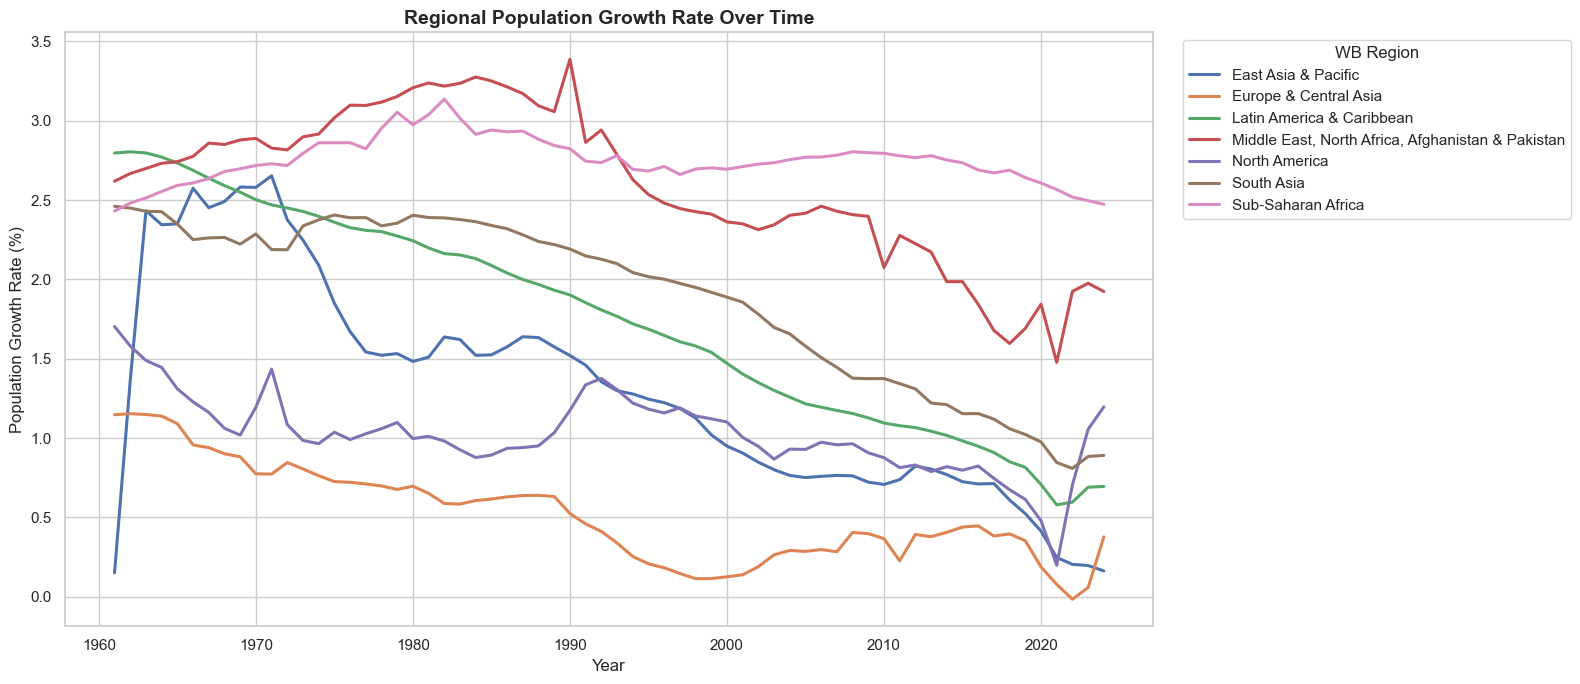

In [7]:
plt.figure(figsize=(16, 7))

sns.lineplot(
    data=pop_region_trend.dropna(subset=["regional_growth_rate_pct"]),
    x="Year",
    y="regional_growth_rate_pct",
    hue="WB Region",
    linewidth=2.2
)

plt.title("Regional Population Growth Rate Over Time", fontsize=14, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Population Growth Rate (%)")
plt.legend(title="WB Region", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


### Insight - Regional Population Growth Rate

This chart highlights how quickly each region’s population is growing.

Key observations:
- Some regions show consistently higher growth rates than others.
- In some regions, the growth rate may gradually decline over time, which can reflect demographic transition.
- Differences in growth rate suggest that population change does not happen uniformly across the world.

Conclusion:
Regional population growth patterns vary significantly, which means the drivers of population change are likely different across regions.


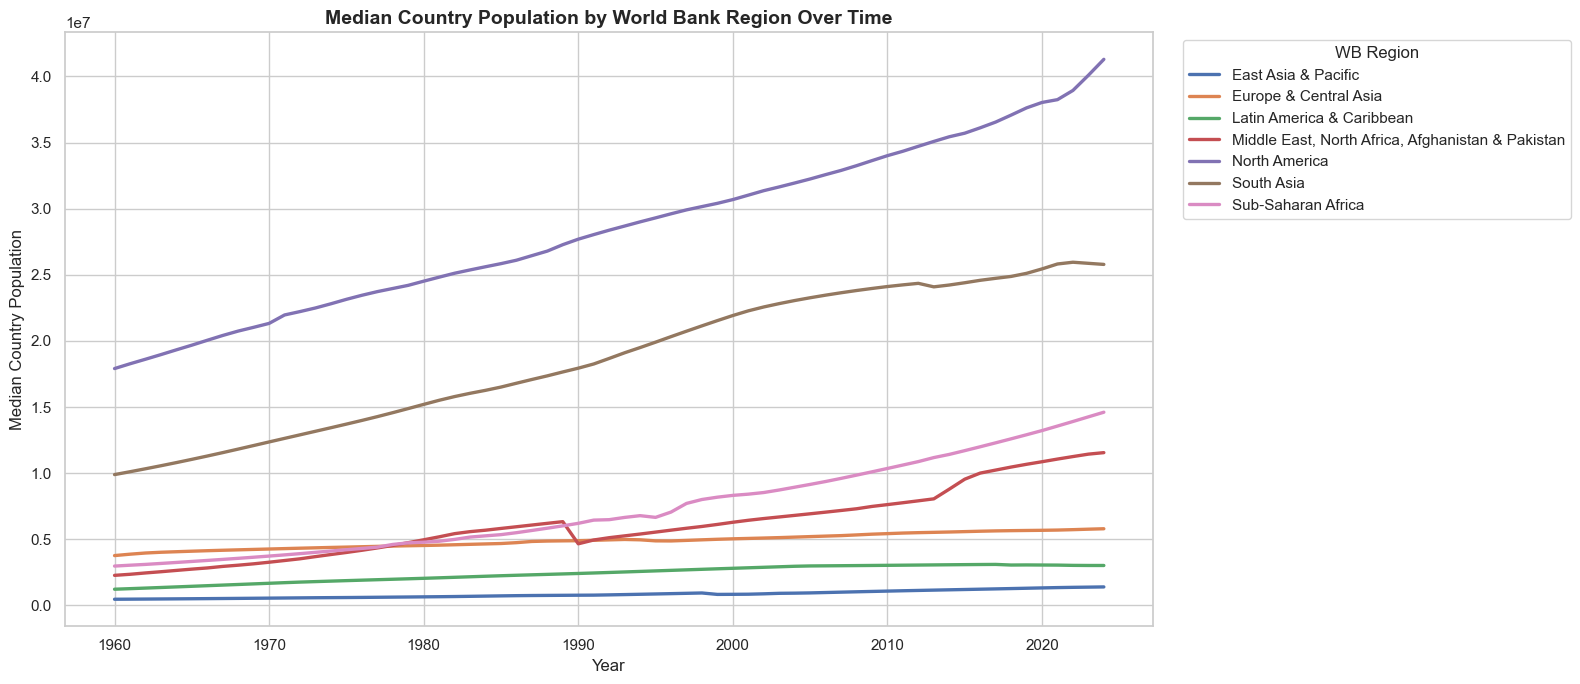

In [8]:
plt.figure(figsize=(16, 7))

sns.lineplot(
    data=pop_region_trend,
    x="Year",
    y="median_population",
    hue="WB Region",
    linewidth=2.4
)

plt.title("Median Country Population by World Bank Region Over Time", fontsize=14, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Median Country Population")
plt.legend(title="WB Region", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


### Insight - Median Country Population by Region

This chart gives a better view of the typical country within each region.

Key observations:
- Median population can differ substantially from total regional population.
- Some regions may have large total populations because of a few very large countries rather than because all countries are large.
- This chart helps separate overall regional size from the typical country-level population pattern.

Conclusion:
The median chart provides a more balanced interpretation of regional population structure and helps avoid relying only on totals.


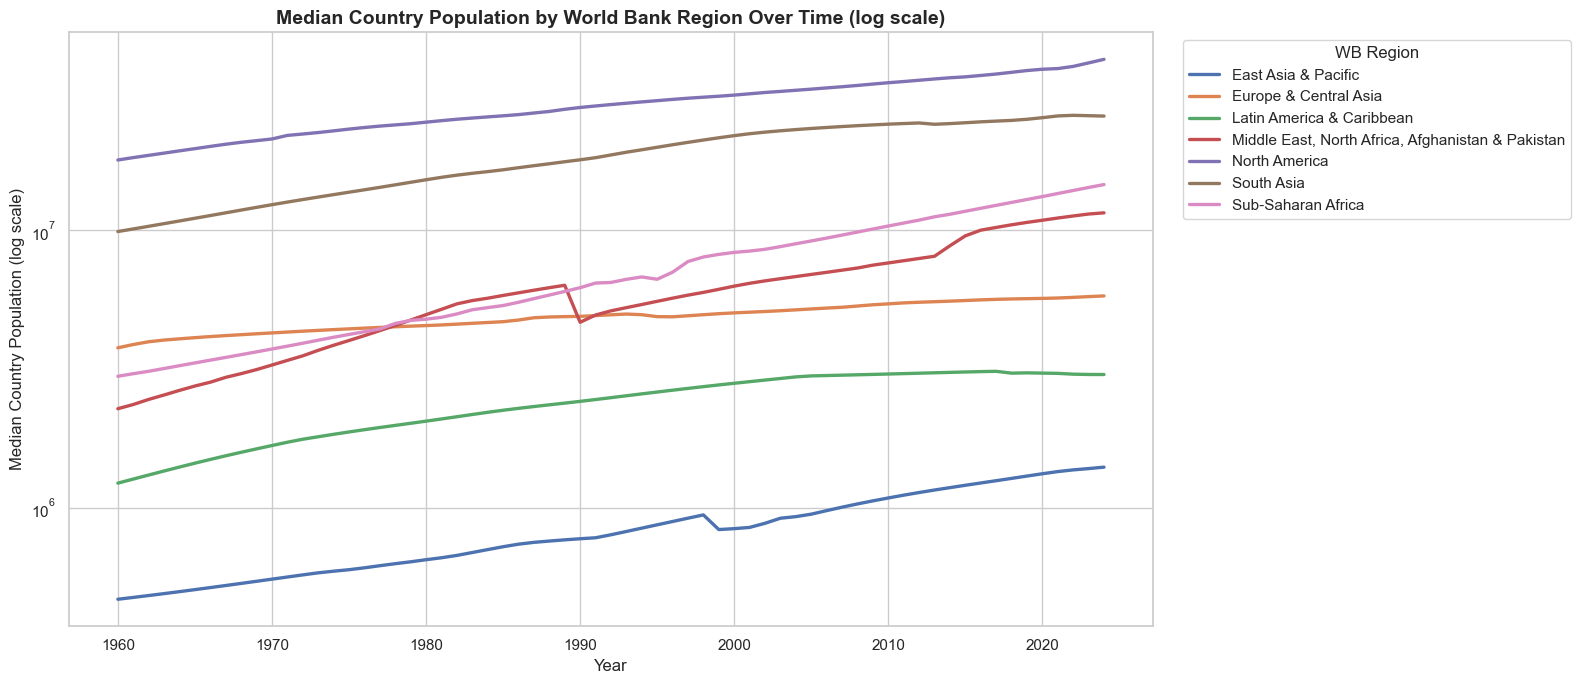

In [12]:
plt.figure(figsize=(16, 7))

sns.lineplot(
    data=pop_region_trend,
    x="Year",
    y="median_population",
    hue="WB Region",
    linewidth=2.4
)

plt.yscale("log")
plt.title("Median Country Population by World Bank Region Over Time (log scale)", fontsize=14, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Median Country Population (log scale)")
plt.legend(title="WB Region", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


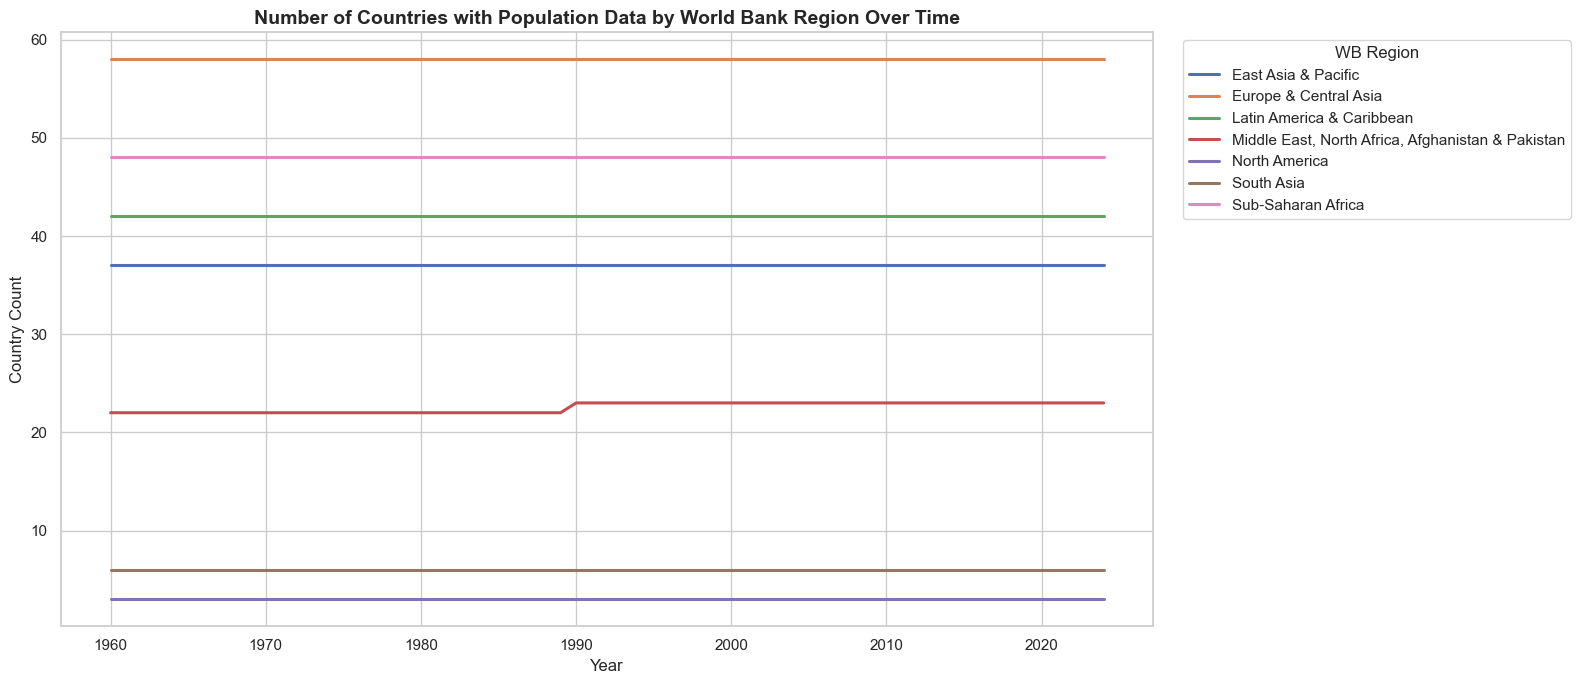

In [9]:
plt.figure(figsize=(16, 7))

sns.lineplot(
    data=pop_region_trend,
    x="Year",
    y="country_count",
    hue="WB Region",
    linewidth=2.2
)

plt.title("Number of Countries with Population Data by World Bank Region Over Time", fontsize=14, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Country Count")
plt.legend(title="WB Region", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


### Insight - Data Coverage by Region

This chart helps evaluate how complete the population dataset is across time and regions.

Key observations:
- Coverage is generally strong, especially compared with some other indicators such as GDP.
- If country counts remain stable, the regional time-series comparison becomes more reliable.
- Small drops or changes in coverage should still be noted when interpreting the earliest or latest years.

Conclusion:
Population data appears relatively complete across regions, which supports stronger confidence in long-term trend analysis.


In [10]:
latest_year = int(pop_region_trend["Year"].max())

pop_latest_region = (
    pop_region_trend[pop_region_trend["Year"] == latest_year]
    .sort_values("total_population", ascending=False)
    .reset_index(drop=True)
)

print("Latest year:", latest_year)
pop_latest_region


Latest year: 2024


,WB Region,Year,country_count,total_population,mean_population,median_population,min_population,max_population,regional_growth_rate_pct,global_total_population,population_share_pct
0,East Asia & Pacific,2024,37,2.364907e+09,6.391639e+07,1400638.0,9646.0,1.408975e+09,0.162570,8.118396e+09,29.130220
1,South Asia,2024,6,1.677385e+09,2.795641e+08,25783527.0,527799.0,1.450936e+09,0.890420,8.118396e+09,20.661526
2,Sub-Saharan Africa,2024,48,1.291045e+09,2.689677e+07,14608754.5,121354.0,2.326795e+08,2.472835,8.118396e+09,15.902710
3,Europe & Central Asia,2024,58,9.282632e+08,1.600454e+07,5798451.5,33977.0,1.435339e+08,0.377356,8.118396e+09,11.434071
4,"Middle East, North Africa, Afghanistan & Pakistan",2024,23,8.131461e+08,3.535418e+07,11552876.0,568847.0,2.512692e+08,1.923371,8.118396e+09,10.016093
5,Latin America & Caribbean,2024,42,6.621864e+08,1.576634e+07,3021235.0,26129.0,2.119986e+08,0.694914,8.118396e+09,8.156616
6,North America,2024,3,3.814642e+08,1.271547e+08,41288599.0,64636.0,3.401110e+08,1.196381,8.118396e+09,4.698763


In [11]:
largest_region = pop_latest_region.iloc[0]
smallest_region = pop_latest_region.iloc[-1]

print(f"Latest year in the dataset: {latest_year}")
print(f"Largest population region: {largest_region['WB Region']} ({largest_region['total_population']:,.0f})")
print(f"Smallest population region: {smallest_region['WB Region']} ({smallest_region['total_population']:,.0f})")
print(f"Highest population share region: {pop_latest_region.sort_values('population_share_pct', ascending=False).iloc[0]['WB Region']}")
print("Interpretation note: total population and population share are the most meaningful measures for regional population analysis.")


Latest year in the dataset: 2024
Largest population region: East Asia & Pacific (2,364,906,595)
Smallest population region: North America (381,464,223)
Highest population share region: East Asia & Pacific
Interpretation note: total population and population share are the most meaningful measures for regional population analysis.
